In [1]:
import pandas as pd

trials = pd.read_csv("../data/raw/ctgov_metastatic_breast_cancer_trials.csv")
trials.head()


,NCT Number,Study Title,Study URL,Study Status,Conditions,Interventions,Sponsor,Collaborators,Study Type
0,NCT02229149,Phase 2 Study of Standard Chemotherapy With Tr...,https://clinicaltrials.gov/study/NCT02229149,TERMINATED,Breast Neoplasms|Malignant Tumor of the Breast,DRUG: Trastuzumab|DRUG: Pertuzumab|DRUG: Vinor...,US Oncology Research,"Genentech, Inc.",INTERVENTIONAL
1,NCT01906112,Role of Surgery for the Primary in Patients Wi...,https://clinicaltrials.gov/study/NCT01906112,WITHDRAWN,Carcinoma Breast Stage IV,PROCEDURE: Surgery for primary breast tumor.,"National Cancer Institute, Thailand",Vichaiyut Hospital,INTERVENTIONAL
2,NCT02755272,A Study of Pembrolizumab With Carboplatin and ...,https://clinicaltrials.gov/study/NCT02755272,ACTIVE_NOT_RECRUITING,Carcinoma Breast Stage IV,DRUG: Pembrolizumab|DRUG: Carboplatin|DRUG: Ge...,Fox Chase Cancer Center,"University of Wisconsin, Madison",INTERVENTIONAL
3,NCT02183805,Chemotherapy Followed by Peripheral Stem Cell ...,https://clinicaltrials.gov/study/NCT02183805,TERMINATED,Carcinoma Breast Stage IV,"DRUG: Abraxane,Cyclophosphamide,Carboplatin",Sun Yat-sen University,NaN,INTERVENTIONAL
4,NCT03847220,Study of the Utility of the BOMET-QOL Question...,https://clinicaltrials.gov/study/NCT03847220,COMPLETED,Breast Carcinoma Metastatic to the Bone,DIAGNOSTIC_TEST: BOMET-QoL questionnaire,Spanish Breast Cancer Research Group,Novartis Pharmaceuticals,OBSERVATIONAL


In [2]:
trials.columns


Index(['NCT Number', 'Study Title', 'Study URL', 'Study Status', 'Conditions',
       'Interventions', 'Sponsor', 'Collaborators', 'Study Type'],
      dtype='object')

In [3]:
# Rename columns to simpler snake_case
trials_clean = trials.rename(columns={
    "NCT Number": "nct_id",
    "Study Title": "title",
    "Study URL": "url",
    "Study Status": "status",
    "Conditions": "conditions",
    "Interventions": "interventions",
    "Sponsor": "sponsor",
    "Collaborators": "collaborators",
    "Study Type": "study_type"
})

# Remove duplicates
trials_clean = trials_clean.drop_duplicates(subset=["nct_id"])

# Strip whitespace
for col in trials_clean.columns:
    trials_clean[col] = trials_clean[col].astype(str).str.strip()

trials_clean.head()


,nct_id,title,url,status,conditions,interventions,sponsor,collaborators,study_type
0,NCT02229149,Phase 2 Study of Standard Chemotherapy With Tr...,https://clinicaltrials.gov/study/NCT02229149,TERMINATED,Breast Neoplasms|Malignant Tumor of the Breast,DRUG: Trastuzumab|DRUG: Pertuzumab|DRUG: Vinor...,US Oncology Research,"Genentech, Inc.",INTERVENTIONAL
1,NCT01906112,Role of Surgery for the Primary in Patients Wi...,https://clinicaltrials.gov/study/NCT01906112,WITHDRAWN,Carcinoma Breast Stage IV,PROCEDURE: Surgery for primary breast tumor.,"National Cancer Institute, Thailand",Vichaiyut Hospital,INTERVENTIONAL
2,NCT02755272,A Study of Pembrolizumab With Carboplatin and ...,https://clinicaltrials.gov/study/NCT02755272,ACTIVE_NOT_RECRUITING,Carcinoma Breast Stage IV,DRUG: Pembrolizumab|DRUG: Carboplatin|DRUG: Ge...,Fox Chase Cancer Center,"University of Wisconsin, Madison",INTERVENTIONAL
3,NCT02183805,Chemotherapy Followed by Peripheral Stem Cell ...,https://clinicaltrials.gov/study/NCT02183805,TERMINATED,Carcinoma Breast Stage IV,"DRUG: Abraxane,Cyclophosphamide,Carboplatin",Sun Yat-sen University,nan,INTERVENTIONAL
4,NCT03847220,Study of the Utility of the BOMET-QOL Question...,https://clinicaltrials.gov/study/NCT03847220,COMPLETED,Breast Carcinoma Metastatic to the Bone,DIAGNOSTIC_TEST: BOMET-QoL questionnaire,Spanish Breast Cancer Research Group,Novartis Pharmaceuticals,OBSERVATIONAL


In [4]:
trials_clean = trials_clean[
    trials_clean["conditions"].str.lower().str.contains("breast")
]


In [5]:
import re

def extract_phase(text):
    text = text.lower()
    if "phase 3" in text or "phase iii" in text:
        return "Phase 3"
    if "phase 2" in text or "phase ii" in text:
        return "Phase 2"
    if "phase 1" in text or "phase i" in text:
        return "Phase 1"
    return "Unknown"

trials_clean["phase"] = trials_clean["title"].apply(extract_phase)
trials_clean["phase"].value_counts()


phase
Unknown    3802
Phase 2     138
Phase 1     134
Phase 3      33
Name: count, dtype: int64

In [6]:
trials_clean.to_csv("../data/processed/clean_clinical_trials.csv", index=False)


In [7]:
phase_summary = trials_clean["phase"].value_counts().reset_index()
phase_summary.columns = ["phase", "count"]
phase_summary


,phase,count
0,Unknown,3802
1,Phase 2,138
2,Phase 1,134
3,Phase 3,33


#### Plot Phase Distribution

Matplotlib is building the font cache; this may take a moment.


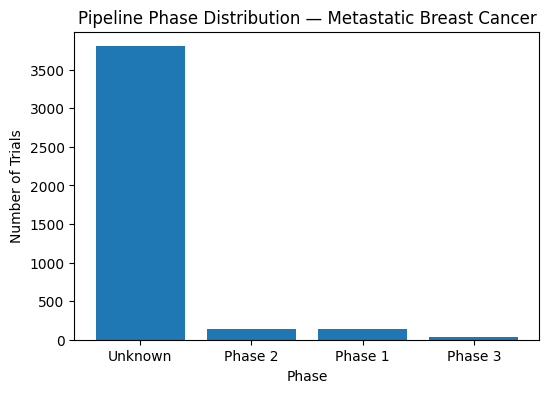

In [8]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(phase_summary["phase"], phase_summary["count"])
plt.title("Pipeline Phase Distribution — Metastatic Breast Cancer")
plt.xlabel("Phase")
plt.ylabel("Number of Trials")
plt.xticks(rotation=0)
plt.show()


#### Sponsor Analysis (Which companies are dominant?)

In [9]:
sponsor_counts = (
    trials_clean["sponsor"]
    .value_counts()
    .reset_index()
    .head(20)
)

sponsor_counts.columns = ["sponsor", "count"]
sponsor_counts


,sponsor,count
0,National Cancer Institute (NCI),177
1,Fudan University,103
2,Hoffmann-La Roche,98
3,Pfizer,86
4,Novartis Pharmaceuticals,83
5,AstraZeneca,82
6,M.D. Anderson Cancer Center,72
7,Memorial Sloan Kettering Cancer Center,70
8,Eli Lilly and Company,64
9,Dana-Farber Cancer Institute,49


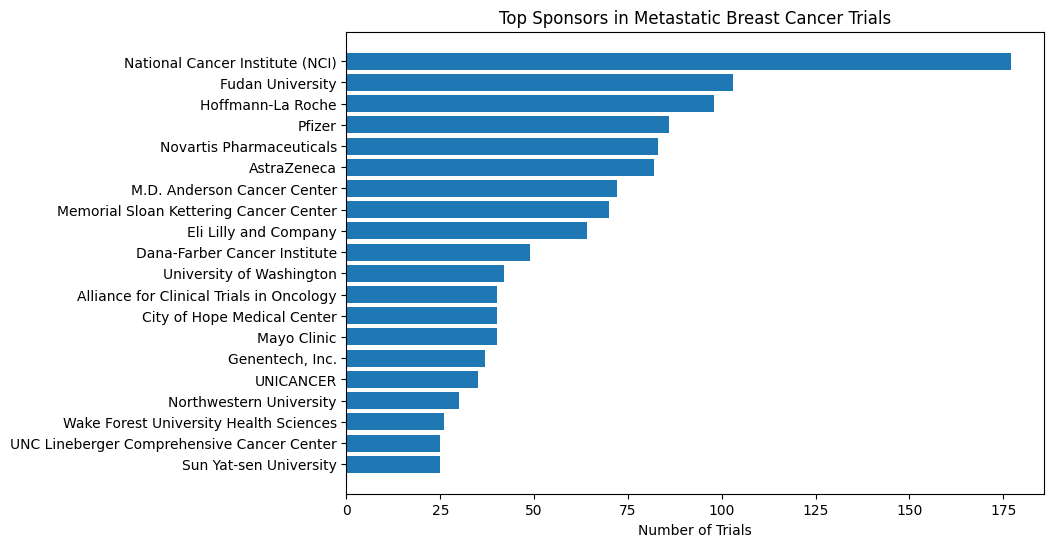

In [10]:
plt.figure(figsize=(9,6))
plt.barh(sponsor_counts["sponsor"], sponsor_counts["count"])
plt.title("Top Sponsors in Metastatic Breast Cancer Trials")
plt.xlabel("Number of Trials")
plt.gca().invert_yaxis()
plt.show()


In [11]:
status_summary = trials_clean["status"].value_counts().reset_index()
status_summary.columns = ["status", "count"]
status_summary


,status,count
0,COMPLETED,1875
1,RECRUITING,611
2,TERMINATED,538
3,UNKNOWN,412
4,ACTIVE_NOT_RECRUITING,321
5,WITHDRAWN,156
6,NOT_YET_RECRUITING,152
7,SUSPENDED,16
8,ENROLLING_BY_INVITATION,11
9,APPROVED_FOR_MARKETING,8


In [12]:
import pandas as pd

def extract_keywords(text):
    text = text.lower()
    keywords = ["antibody", "chemotherapy", "immunotherapy", "hormone", "targeted", "inhibitor", "cdk4/6", "her2"]
    found = [kw for kw in keywords if kw in text]
    return ", ".join(found) if found else "other"

trials_clean["keyword"] = trials_clean["interventions"].apply(extract_keywords)

keyword_summary = trials_clean["keyword"].value_counts().reset_index()
keyword_summary.columns = ["keyword", "count"]
keyword_summary


,keyword,count
0,other,3867
1,inhibitor,77
2,chemotherapy,75
3,antibody,27
4,her2,21
5,"inhibitor, cdk4/6",8
6,targeted,8
7,hormone,7
8,"antibody, her2",5
9,immunotherapy,4


In [13]:
trials_clean.to_csv("../data/processed/clean_clinical_trials_with_ci_segments.csv", index=False)
phase_summary.to_csv("../reports/phase_summary.csv", index=False)
sponsor_counts.to_csv("../reports/top_sponsors.csv", index=False)
keyword_summary.to_csv("../reports/keyword_summary.csv", index=False)
status_summary.to_csv("../reports/status_summary.csv", index=False)
